In [29]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import neurokit2 as nk
import spikeinterface.extractors as se
import matplotlib.pyplot as plt
import h5py
import glob
import glob
import os
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
from scipy.signal import find_peaks
import neurokit2 as nk

In [30]:
H5_DIRS = {
    # --- RI1 ---
    "RI1_day1": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs",
    "RI1_day2": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs",

    # --- RI2 post ---
    "RI2_post_d1": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs",
    "RI2_post_d2": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs",
}


In [116]:
def load_clean_resp_signal_ecu(h5_file, target_rate=100, fs=20000):
    """
    Loads, filters, downsamples respiration from ECU-style .h5.
    Preserves original preprocessing logic.
    
    Returns:
        rsp_cleaned : np.ndarray
        time_vector : np.ndarray
        fs_out      : float (target_rate)
        metadata    : dict
    """

    try:
        with h5py.File(h5_file, 'r') as f:

            # -----------------------------
            # Load respiration (ECU Ain1)
            # -----------------------------
            analog_keys = list(f['analog'].keys())
            resp_keys = [k for k in analog_keys if "Ain1" in k]
            if len(resp_keys) == 0:
                raise RuntimeError("No ECU Ain1 channel found")

            resp_key = resp_keys[0]
            resp = f['analog'][resp_key][()]['voltage'].astype(float)

            # -----------------------------
            # Metadata (keep for compatibility)
            # -----------------------------
            metadata = {
                "fs_original": fs,
                "source": "ECU_Ain1",
                "file": os.path.basename(h5_file)
            }

    except Exception as e:
        print(f" Error loading {os.path.basename(h5_file)}: {e}")
        return None, None, None, None

    # -----------------------------
    # PRE-CLEAN (CRITICAL)
    # -----------------------------
    # Remove NaNs / infs
    bad = ~np.isfinite(resp)
    if np.any(bad):
        resp[bad] = np.nanmedian(resp)

    # Remove DC offset
    resp = resp - np.median(resp)

    # Clip extreme artifacts (opto / motion)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # -----------------------------
    # Low-pass before downsampling
    # -----------------------------
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # -----------------------------
    # Downsample
    # -----------------------------
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # -----------------------------
    # Bandpass (NeuroKit)
    # -----------------------------
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # -----------------------------
    # Time vector
    # -----------------------------
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata

In [32]:
def get_sniff_respiratory_rate(
    signal,
    time,
    sniff_start,
    sniff_end,
    sampling_rate=100,
    max_rate_hz=12
):
    """
    Compute average respiration/sniff rate using inter-breath intervals (IBI).
    
    Returns:
        avg_rate_hz (float) or np.nan
    """

    # -----------------------------
    # Mask window
    # -----------------------------
    sniff_mask = (time >= sniff_start) & (time < sniff_end)

    if sniff_mask.sum() < sampling_rate:  # <1 s of data
        return np.nan

    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # -----------------------------
    # Pre-clean for peak detection
    # -----------------------------
    signal_sniff = signal_sniff - np.mean(signal_sniff)

    # -----------------------------
    # Peak detection
    # -----------------------------
    min_ibi = 1.0 / max_rate_hz
    min_distance = int(min_ibi * sampling_rate)

    peaks, _ = find_peaks(
        signal_sniff,
        distance=min_distance
    )

    if len(peaks) < 2:
        return np.nan

    # -----------------------------
    # IBI and rate
    # -----------------------------
    peak_times = time_sniff[peaks]
    ibi = np.diff(peak_times)          # seconds
    inst_rate = 1.0 / ibi              # Hz

    return np.mean(inst_rate)


In [33]:
import h5py

h5_file = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\1_1_RI1_f1_d_on_20260111_164638.h5"

with h5py.File(h5_file, "r") as f:
    print("DIO keys:", f["dio"].keys())



DIO keys: <KeysViewHDF5 ['1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1', '1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1']>


In [34]:
with h5py.File(h5_file, "r") as f:
    for k in f["dio"].keys():
        dset = f["dio"][k]
        print("\nDIO key:", k)
        print("Type:", type(dset))
        print("Dtype:", dset.dtype)
        print("Dtype names:", dset.dtype.names)
        print("Shape:", dset.shape)




DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (6547,)

DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (1,)


In [35]:
with h5py.File(h5_file, "r") as f:
    print("Time group keys:", f["time"].keys())



Time group keys: <KeysViewHDF5 ['1_1_RI1_f1_d_on_20260111_164638.timestamps']>


In [36]:
def extract_laser_ttl_times_ecu(h5_file, trodes_rate=20000):
    """
    Extract rising-edge laser TTL pulse times (seconds)
    from ECU_Din1 using Trodes clock ticks (20 kHz).
    """
    import h5py
    import numpy as np

    with h5py.File(h5_file, "r") as f:
        # Find ECU_Din1 (laser pulses)
        dio_keys = [k for k in f["dio"].keys() if "ECU_Din1" in k]
        if len(dio_keys) == 0:
            return np.array([])

        dio = f["dio"][dio_keys[0]][()]
        dio_ticks = dio["time"].astype(float)   # Trodes ticks
        dio_states = dio["state"].astype(int)   # 0 / 1

    # Rising edges (0 → 1)
    rising_edges = np.where(np.diff(dio_states) == 1)[0]

    # Convert ticks → seconds
    pulse_times_sec = dio_ticks[rising_edges] / trodes_rate

    return pulse_times_sec


In [37]:
with h5py.File(h5_file, "r") as f:
    time_key = list(f["time"].keys())[0]
    global_time = f["time"][time_key][()]

print(global_time.dtype.names)



('time', 'systime')


In [38]:
pulse_times = extract_laser_ttl_times_ecu(h5_file)

print("Total pulses:", len(pulse_times))
print("First pulse (s):", pulse_times[0])
print("Last pulse (s):", pulse_times[-1])

print("Baseline pulses:", np.sum(pulse_times < 60))
print("RI pulses:", np.sum((pulse_times >= 60) & (pulse_times <= 240)))


Total pulses: 3273
First pulse (s): 321.66025
Last pulse (s): 564.12595
Baseline pulses: 0
RI pulses: 0


In [93]:
def load_resp_simple(h5_file, target_rate=100, trodes_rate=20000):
    import h5py
    import numpy as np
    from scipy.signal import butter, filtfilt, resample_poly
    import neurokit2 as nk

    with h5py.File(h5_file, 'r') as f:
        resp_key = [k for k in f['analog'].keys() if "Ain1" in k][0]
        resp = f['analog'][resp_key][()]['voltage'].astype(float)

    # Time relative to recording start
    t = np.arange(len(resp)) / trodes_rate

    # Clean
    resp -= np.median(resp)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # Low-pass + downsample
    nyq = trodes_rate / 2
    b, a = butter(4, (target_rate / 2) / nyq, btype="low")
    resp_filt = filtfilt(b, a, resp)

    down = int(trodes_rate // target_rate)
    resp_ds = resample_poly(resp_filt, up=1, down=down)
    t_ds = t[::down]

    # Bandpass
    resp_clean = nk.signal_filter(
        resp_ds,
        lowcut=0.1,
        highcut=20,
        sampling_rate=target_rate,
        order=2
    )

    return resp_clean, t_ds


In [94]:
SOCIAL_START = 60
SOCIAL_END   = 240


In [95]:
rsp, t = load_resp_simple(h5_file)

social_rate = get_sniff_respiratory_rate(
    signal=rsp,
    time=t,
    sniff_start=SOCIAL_START,
    sniff_end=SOCIAL_END,
    sampling_rate=100
)

print("Social respiration rate (Hz):", social_rate)


Social respiration rate (Hz): 5.248762701771318


In [104]:
import numpy as np
import pandas as pd
import os

SOCIAL_START = 60
SOCIAL_END   = 240

rows = []

for h5_file in all_files:
    
    fname = os.path.basename(h5_file)
    parts = fname.split("_")
    
    subject = "_".join(parts[0:2])
    condition = parts[2]
    laser = "ON" if "_on_" in fname else "OFF"
    
    try:
        rsp, t = load_resp_simple(h5_file)
        
        rate = get_sniff_respiratory_rate(
            signal=rsp,
            time=t,
            sniff_start=SOCIAL_START,
            sniff_end=SOCIAL_END,
            sampling_rate=100
        )
        
        rows.append({
            "Subject": subject,
            "Condition": condition,
            "Laser": laser,
            "RespRate": rate,
            "File": fname
        })
        
    except:
        continue

df_resp = pd.DataFrame(rows)

print("Total rows:", len(df_resp))
print("Subjects:", df_resp["Subject"].nunique())
df_resp.head()


Total rows: 94
Subjects: 24


,Subject,Condition,Laser,RespRate,File
0,1_1,RI1,ON,9.152318,1_1_RI1_f1_d_on_20260111_164638.h5
1,1_2,RI1,OFF,10.288113,1_2_RI1_f2_f_off_20260109_165330.h5
2,1_3,RI1,OFF,8.591796,1_3_RI1_f1_c_off_20260110_130254.h5
3,2_1,RI1,ON,9.249470,2_1_RI1_f2_h_on_20260110_145355.h5
4,2_2,RI1,OFF,8.654789,2_2_RI1_f1_b_off_20260109_150435.h5


In [106]:
bad_files = qc_df[qc_df["std"] < 20]["file"]
bad_subjects = set(["_".join(f.split("_")[:2]) for f in bad_files])

df_resp_clean = df_resp[~df_resp["Subject"].isin(bad_subjects)].copy()

print("Subjects removed:", bad_subjects)
print("Remaining subjects:", df_resp_clean["Subject"].nunique())


Subjects removed: {'8_1', '5_2', '2_3', '6_2', '5_3', '4_1', '6_3', '5_1'}
Remaining subjects: 16


In [96]:
import os

all_files = []

for day, folder in H5_DIRS.items():
    for fname in os.listdir(folder):
        if fname.endswith(".h5"):
            all_files.append(os.path.join(folder, fname))

print("Total files found:", len(all_files))


Total files found: 94


In [97]:
for f in all_files[:20]:
    print(os.path.basename(f))


1_1_RI1_f1_d_on_20260111_164638.h5
1_2_RI1_f2_f_off_20260109_165330.h5
1_3_RI1_f1_c_off_20260110_130254.h5
2_1_RI1_f2_h_on_20260110_145355.h5
2_2_RI1_f1_b_off_20260109_150435.h5
2_3_RI1_f2_f_on_20260110_132734.h5
3_1_RI1_f1_b_on_20260111_154618.h5
3_2_RI1_f1_a_off_20260114_161949.h5
3_3_RI1_f1_c_on_20260111_162426.h5
4_1_RI1_f2_h_on_20260111_161337.h5
4_2_RI1_f1_c_off_20260110_150626.h5
4_3_RI1_f2_e_on_20260111_152801.h5
5_1_RI1_m1_j_on_20260111_150428.h5
5_2_RI1_m2_n_off_20260110_135659.h5
5_3_RI1_m1_k_off_20260109_183135.h5
6_2_RI1_m1_j_off_20260109_191750.h5
6_3_RI1_m2_m_off_20260109_174951.h5
7_1_RI1_m1_k_on_20260111_160052.h5
7_2_RI1_m2_o_off_20260109_162132.h5
7_3_RI1_m1_i_on_20260110_142124.h5


In [98]:
from collections import defaultdict
import os

subject_counts = defaultdict(lambda: {"on": 0, "off": 0})

for path in all_files:
    fname = os.path.basename(path)
    subject = "_".join(fname.split("_")[0:2])  # cage_mouse
    
    if "_on_" in fname:
        subject_counts[subject]["on"] += 1
    elif "_off_" in fname:
        subject_counts[subject]["off"] += 1

for subj, counts in subject_counts.items():
    if counts["on"] != counts["off"]:
        print(f"\nSubject mismatch: {subj}")
        print("ON:", counts["on"])
        print("OFF:", counts["off"])


In [99]:
import os

print("Files for subject 5_1:\n")

for path in all_files:
    fname = os.path.basename(path)
    if fname.startswith("5_1_"):
        print(fname)


Files for subject 5_1:

5_1_RI1_m1_j_on_20260111_150428.h5
5_1_RI1_m2_m_off_20260110_174649.h5
5_1_RI2_m2_p_off_20260119_143035.h5
5_1_RI2_m1_j_on_20260120_172322.h5


In [100]:
qc_output_dir = r"D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2"

os.makedirs(qc_output_dir, exist_ok=True)

print("Saving QC plots to:", qc_output_dir)


Saving QC plots to: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2


In [101]:
# Build structured list
structured_files = []

for item in all_files:
    
    h5_file = item["path"] if isinstance(item, dict) else item
    fname = os.path.basename(h5_file)
    
    parts = fname.split("_")
    subject = "_".join(parts[0:2])
    condition = parts[2]
    stim = parts[4]
    laser = "ON" if "_on_" in fname else "OFF"
    
    structured_files.append({
        "path": h5_file,
        "subject": subject,
        "condition": condition,
        "stim": stim,
        "laser": laser
    })

# Sort by subject, condition, stim, and laser (OFF first)
structured_files = sorted(
    structured_files,
    key=lambda x: (x["subject"], x["condition"], x["stim"], x["laser"] == "ON")
)


In [60]:
batch_size = 12

for batch_idx, start in enumerate(range(0, len(structured_files), batch_size)):
    
    batch = structured_files[start:start+batch_size]
    
    fig = plt.figure(figsize=(14, 10))
    
    for i, entry in enumerate(batch):
        
        rsp, t = load_resp_simple(entry["path"])
        
        color = "blue" if entry["laser"] == "ON" else "black"
        alpha = 0.4 if entry["condition"] == "RI2" else 1.0
        
        plt.subplot(4, 3, i+1)
        plt.plot(t, rsp, color=color, linewidth=0.5, alpha=alpha)
        
        plt.title(
            f"{entry['subject']} {entry['condition']} {entry['stim']} {entry['laser']}",
            fontsize=8
        )
        
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout()
    
    # ---- SAVE ----
    save_path = os.path.join(qc_output_dir, f"QC_batch_{batch_idx+1}.png")
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    
    print("Saved:", save_path)
    
    plt.close(fig)



Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_1.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_2.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_3.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_4.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_5.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_6.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_7.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_8.png


In [102]:
on_files = [f for f in all_files if "_on_" in f]
off_files = [f for f in all_files if "_off_" in f]

print("ON files:", len(on_files))
print("OFF files:", len(off_files))


ON files: 47
OFF files: 47


In [62]:
import os

on_subjects = sorted([os.path.basename(f).split("_")[0] + "_" + os.path.basename(f).split("_")[1] 
                      for f in on_files])

off_subjects = sorted([os.path.basename(f).split("_")[0] + "_" + os.path.basename(f).split("_")[1] 
                       for f in off_files])

print("Missing OFF:", set(on_subjects) - set(off_subjects))
print("Missing ON:", set(off_subjects) - set(on_subjects))


Missing OFF: set()
Missing ON: set()


Total files: 94


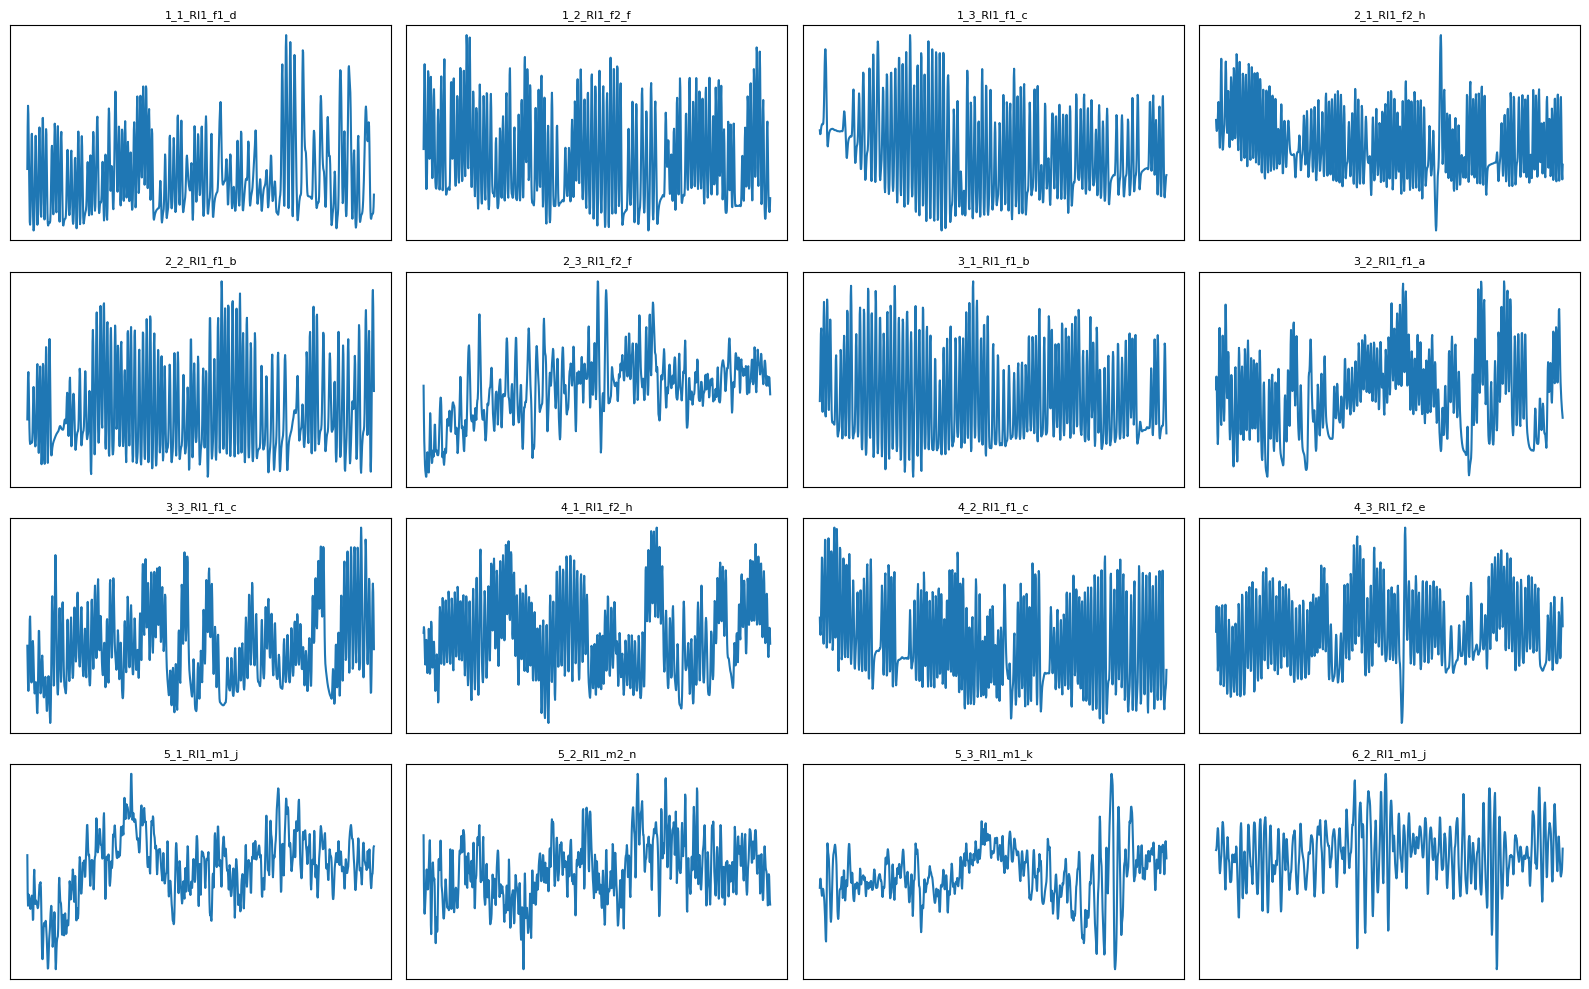

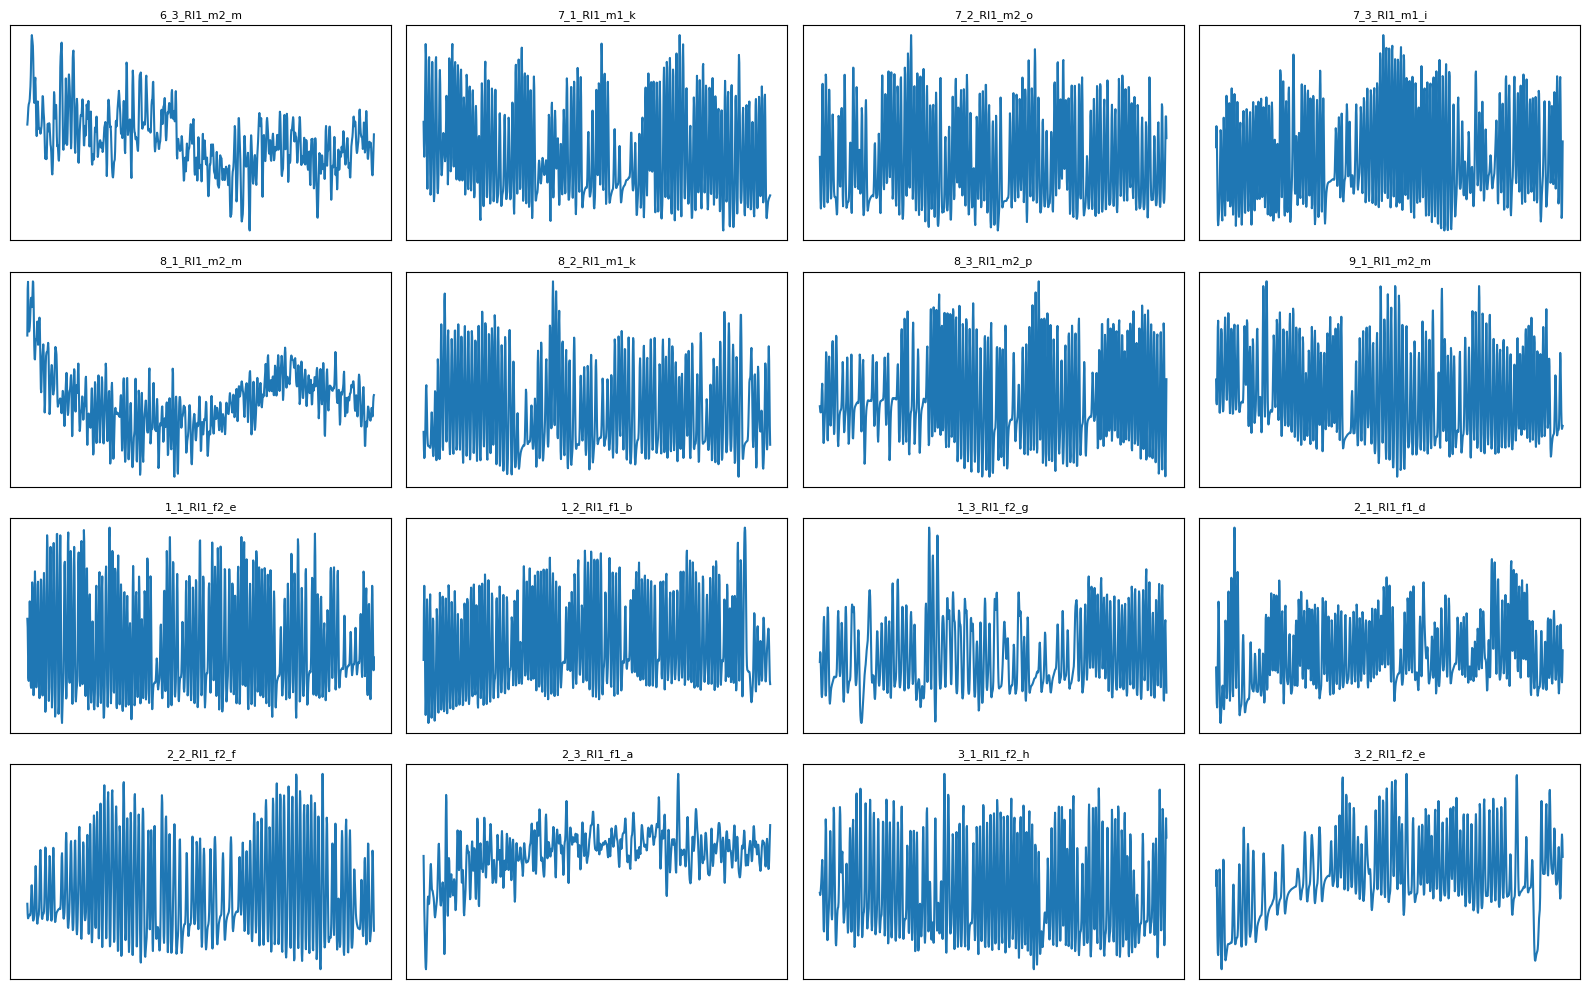

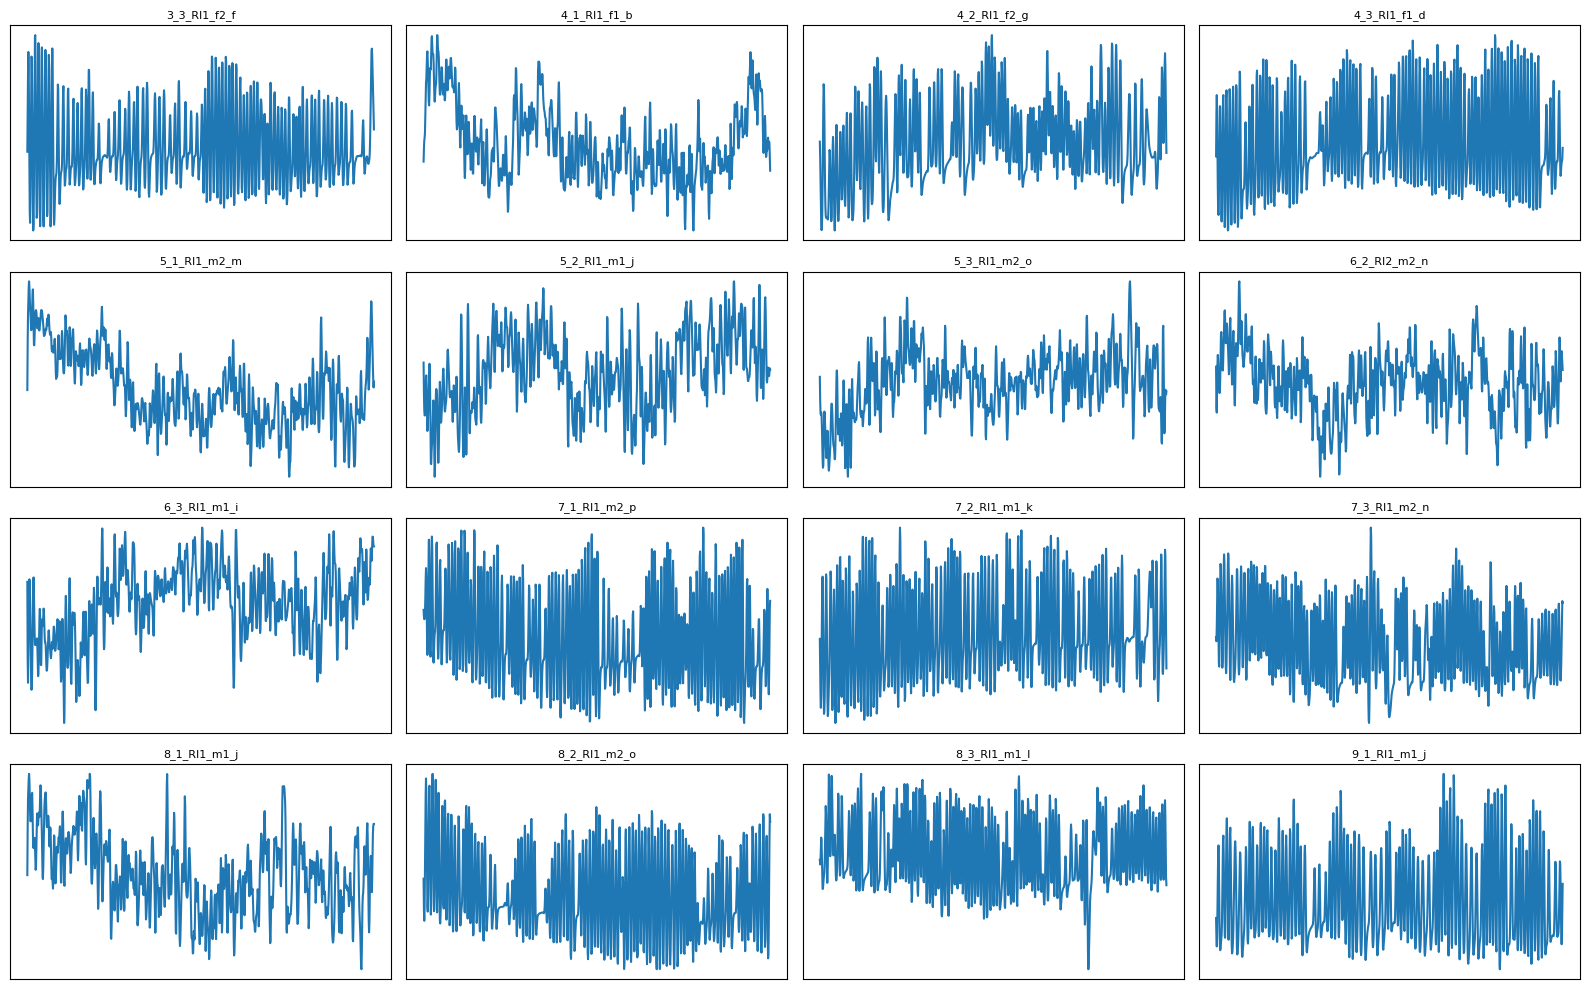

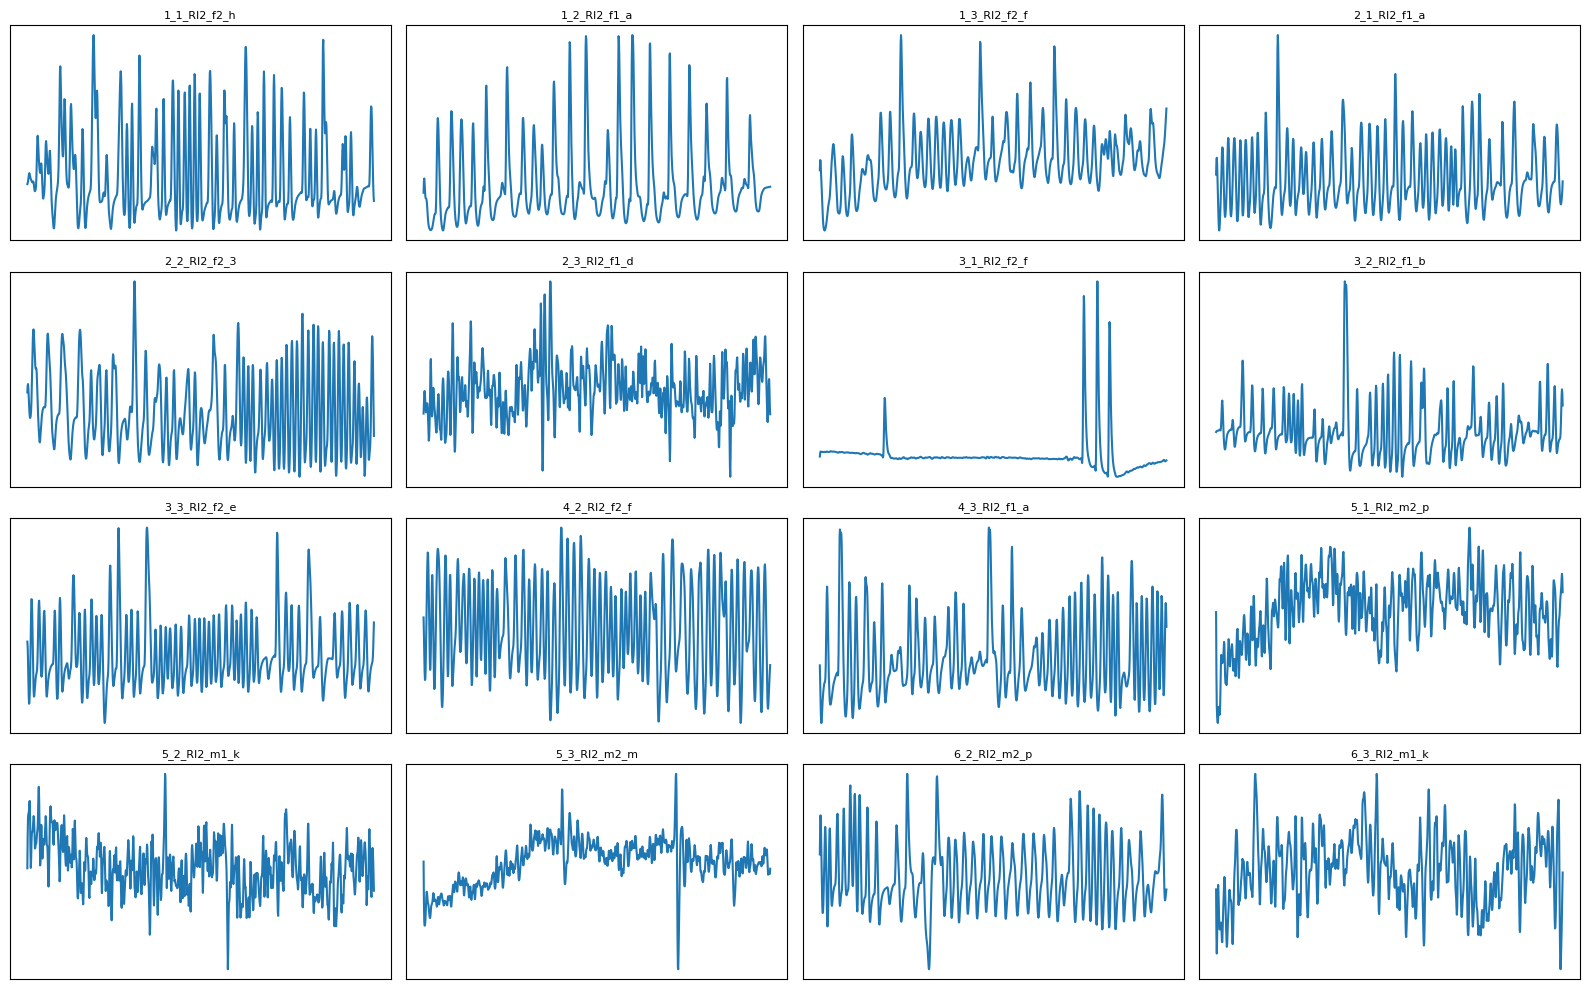

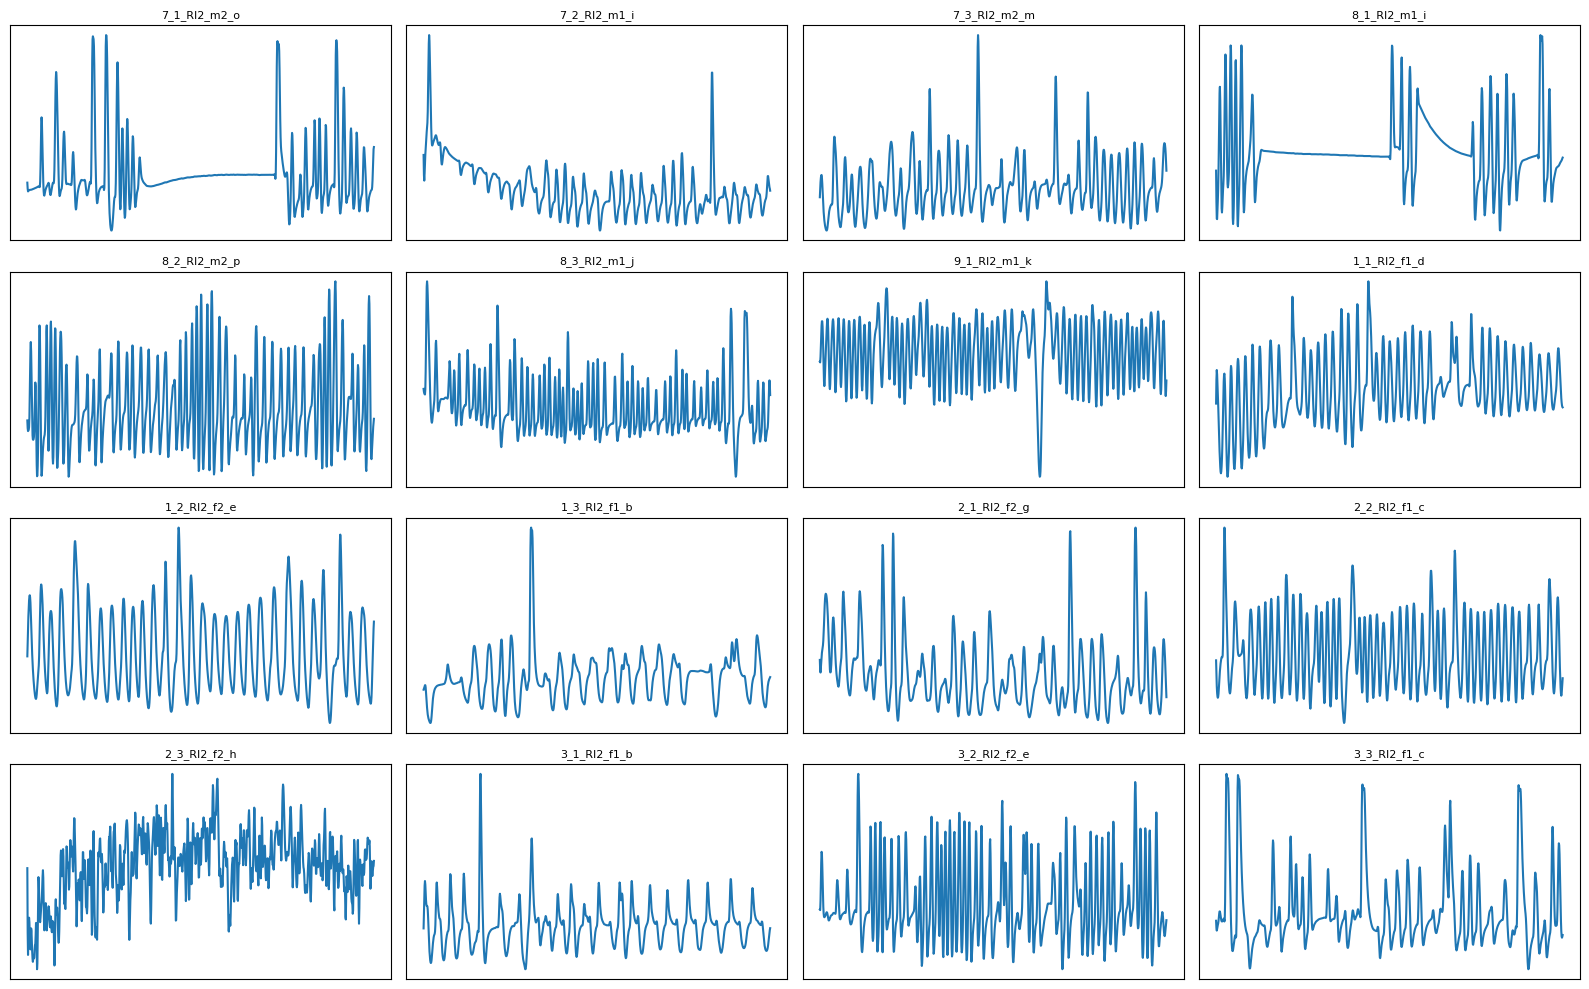

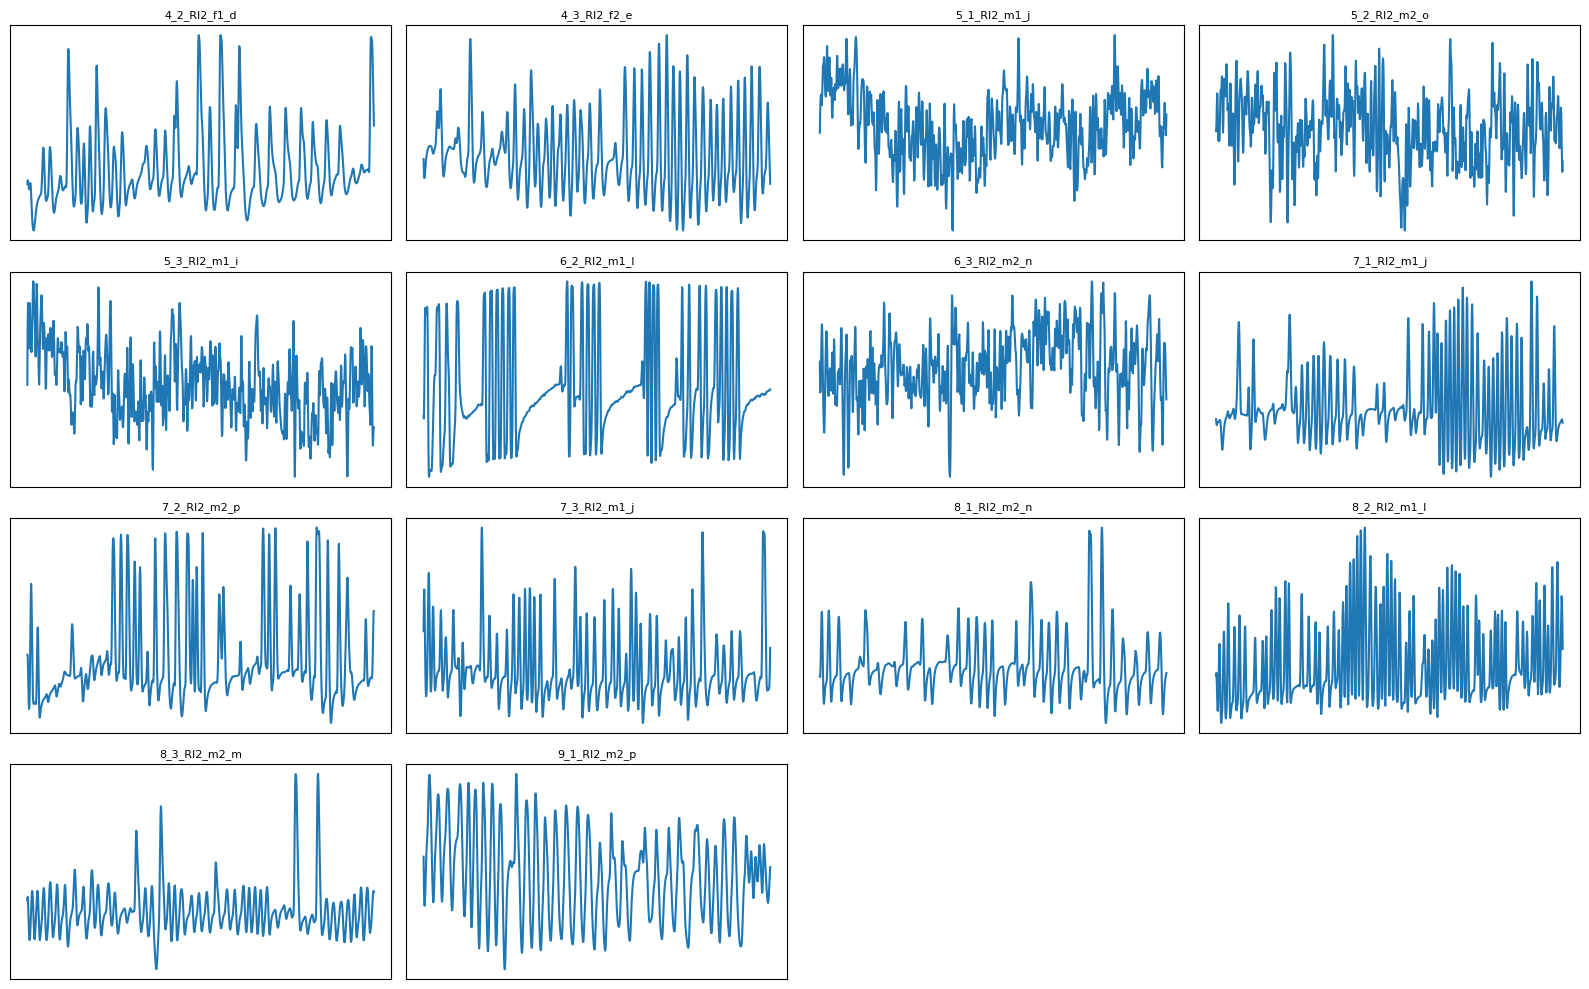

In [63]:
import os
import math
import matplotlib.pyplot as plt

# Combine both days
all_files = []
for folder in H5_DIRS.values():
    for fname in os.listdir(folder):
        if fname.endswith(".h5"):
            all_files.append(os.path.join(folder, fname))

print("Total files:", len(all_files))

batch_size = 16  # show 16 at a time
samples = 1000   # first ~10 seconds (100 Hz)

for start in range(0, len(all_files), batch_size):
    batch = all_files[start:start+batch_size]
    
    cols = 4
    rows = math.ceil(len(batch) / cols)
    
    plt.figure(figsize=(4*cols, 2.5*rows))
    
    for i, h5_file in enumerate(batch):
        rsp, t = load_resp_simple(h5_file)
        
        plt.subplot(rows, cols, i+1)
        plt.plot(t[:samples], rsp[:samples])
        plt.title(os.path.basename(h5_file)[:12], fontsize=8)
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout()
    plt.show()


In [64]:
import numpy as np
import pandas as pd

qc_metrics = []

for h5_file in all_files:
    rsp, t = load_resp_simple(h5_file)
    
    qc_metrics.append({
        "file": os.path.basename(h5_file),
        "std": np.std(rsp),
        "range": np.max(rsp) - np.min(rsp),
        "mean": np.mean(rsp)
    })

qc_df = pd.DataFrame(qc_metrics)

qc_df.sort_values("std")


,file,std,range,mean
84,5_3_RI2_m1_i_off_20260120_155725.h5,0.894183,6.898531,0.009233
83,5_2_RI2_m2_o_off_20260120_134320.h5,0.960066,17.405362,0.003098
86,6_3_RI2_m2_n_off_20260120_114131.h5,1.005168,8.668542,-0.005694
33,4_1_RI1_f1_b_off_20260110_165525.h5,1.110086,9.453438,0.013350
13,5_2_RI1_m2_n_off_20260110_135659.h5,1.207971,10.065365,-0.009803
...,...,...,...,...
52,2_2_RI2_f2_3_on_20260119_144717.h5,936.462965,11037.536078,2.005107
50,1_3_RI2_f2_f_on_20260119_152733.h5,948.559310,8820.529149,-7.250202
67,8_1_RI2_m1_i_off_20260119_162623.h5,1156.394629,7793.736938,-0.209849
70,9_1_RI2_m1_k_off_20260119_153823.h5,1465.629008,12512.426125,-0.808474


In [65]:
qc_df

,file,std,range,mean
0,1_1_RI1_f1_d_on_20260111_164638.h5,398.290569,4448.892152,-0.529422
1,1_2_RI1_f2_f_off_20260109_165330.h5,326.210282,2716.663758,0.307675
2,1_3_RI1_f1_c_off_20260110_130254.h5,277.362850,2673.364308,1.232536
3,2_1_RI1_f2_h_on_20260110_145355.h5,250.412452,2576.901473,1.841883
4,2_2_RI1_f1_b_off_20260109_150435.h5,428.592140,3936.356729,-0.198125
...,...,...,...,...
89,7_3_RI2_m1_j_on_20260120_153051.h5,226.368960,2031.508427,0.397607
90,8_1_RI2_m2_n_on_20260120_132851.h5,266.844618,2359.509083,-0.007007
91,8_2_RI2_m1_l_off_20260120_171457.h5,180.031946,1759.802420,-0.439332
92,8_3_RI2_m2_m_on_20260120_162340.h5,793.858246,7719.137656,-0.886145


Files with STD < 20:
5      2_3_RI1_f2_f_on_20260110_132734.h5
12     5_1_RI1_m1_j_on_20260111_150428.h5
13    5_2_RI1_m2_n_off_20260110_135659.h5
14    5_3_RI1_m1_k_off_20260109_183135.h5
15    6_2_RI1_m1_j_off_20260109_191750.h5
16    6_3_RI1_m2_m_off_20260109_174951.h5
20     8_1_RI1_m2_m_on_20260110_144121.h5
29    2_3_RI1_f1_a_off_20260111_141011.h5
33    4_1_RI1_f1_b_off_20260110_165525.h5
36    5_1_RI1_m2_m_off_20260110_174649.h5
37     5_2_RI1_m1_j_on_20260111_133010.h5
38     5_3_RI1_m2_o_on_20260110_160743.h5
39     6_2_RI2_m2_n_on_20260110_190944.h5
40     6_3_RI1_m1_i_on_20260110_181825.h5
44    8_1_RI1_m1_j_off_20260111_135412.h5
53    2_3_RI2_f1_d_off_20260119_160619.h5
60     5_2_RI2_m1_k_on_20260119_175411.h5
61     5_3_RI2_m2_m_on_20260119_161502.h5
63     6_3_RI2_m1_k_on_20260119_165027.h5
76     2_3_RI2_f2_h_on_20260120_144851.h5
82     5_1_RI2_m1_j_on_20260120_172322.h5
83    5_2_RI2_m2_o_off_20260120_134320.h5
84    5_3_RI2_m1_i_off_20260120_155725.h5
86    6_3_RI2

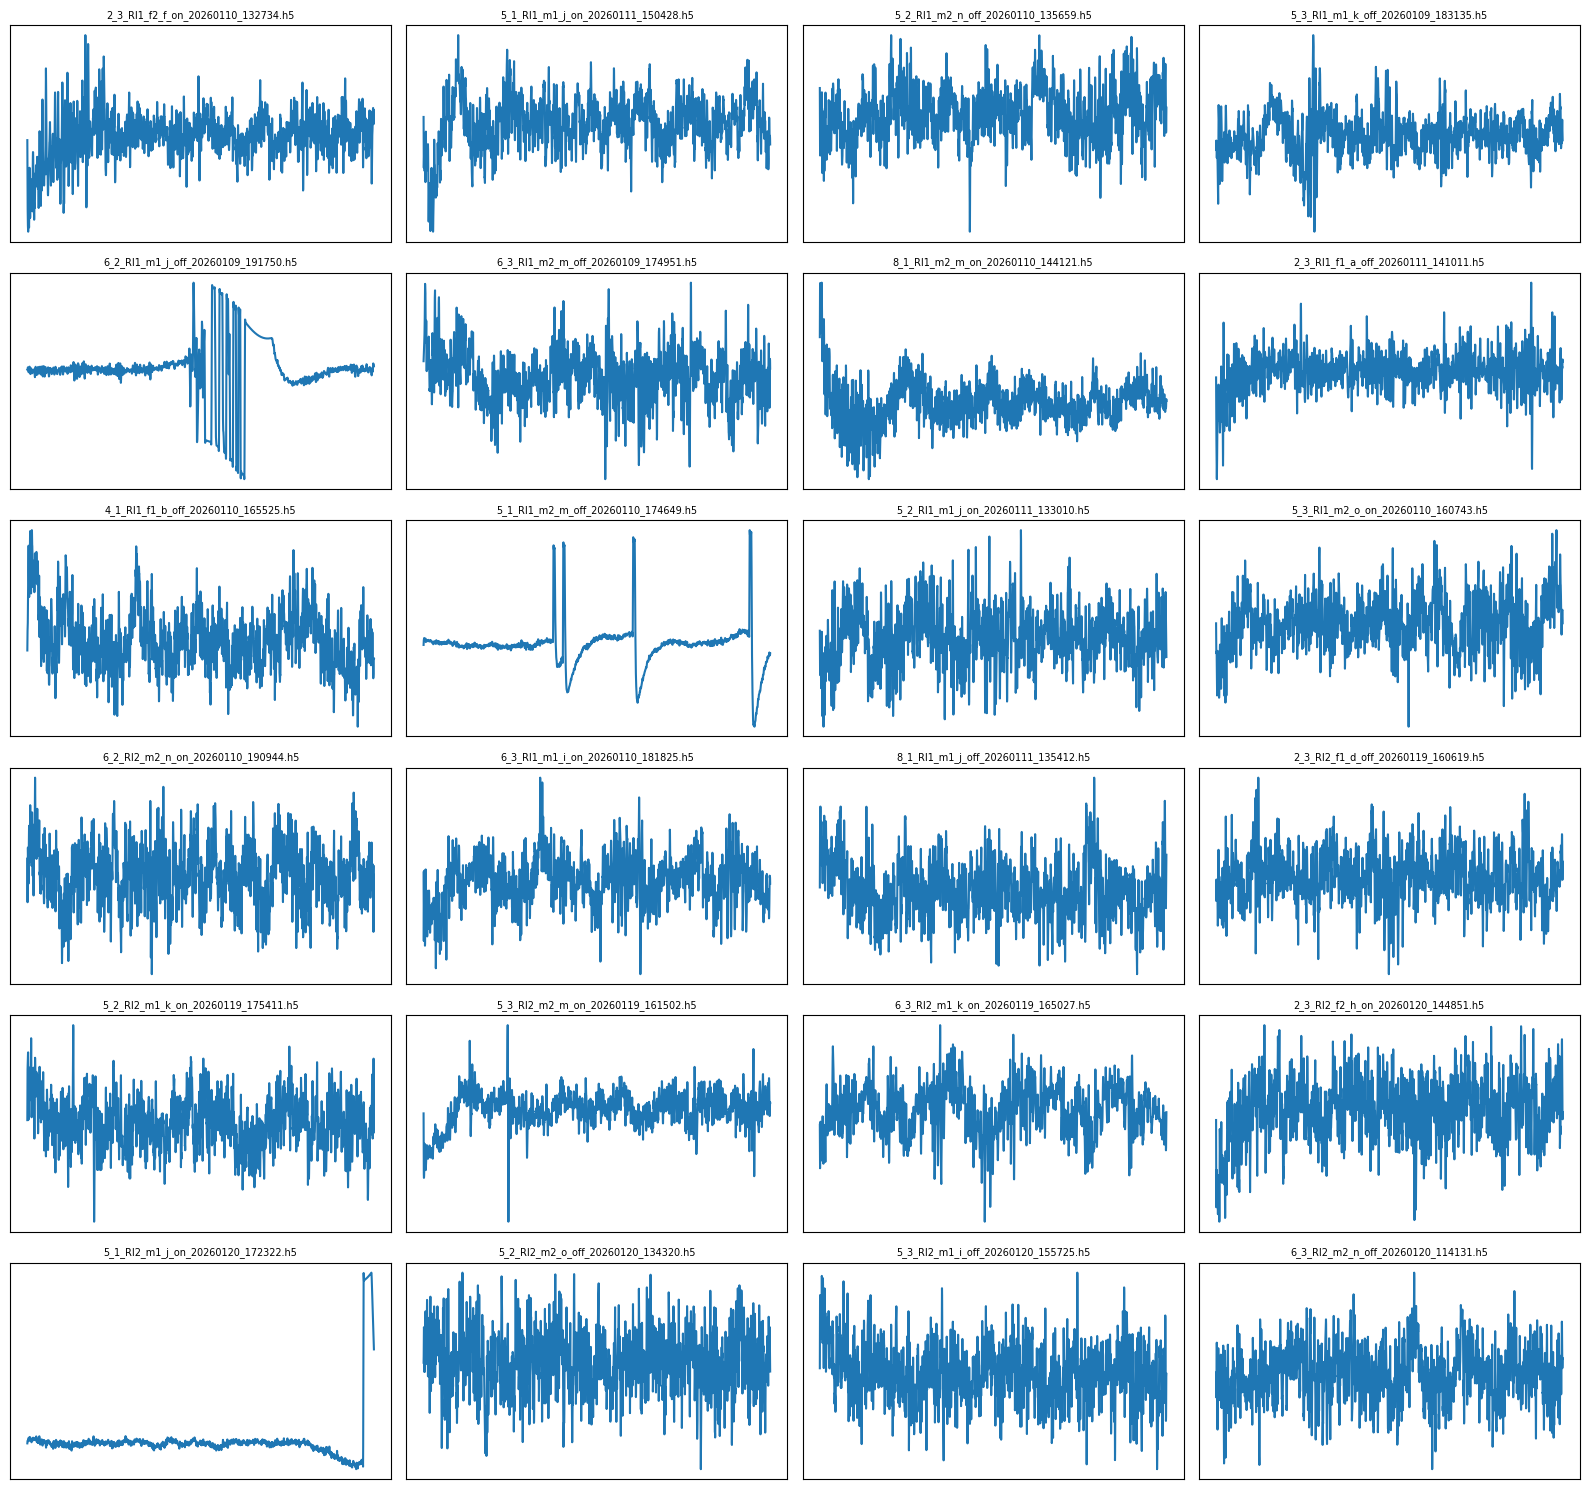

In [83]:
low_std_files = qc_df[qc_df["std"] < 20]["file"]

print("Files with STD < 20:")
print(low_std_files)

import math
import matplotlib.pyplot as plt

low_paths = [f for f in all_files if os.path.basename(f) in low_std_files.values]

cols = 4
rows = math.ceil(len(low_paths) / cols)

plt.figure(figsize=(4*cols, 2.5*rows))

for i, h5_file in enumerate(low_paths):
    rsp, t = load_resp_simple(h5_file)
    plt.subplot(rows, cols, i+1)
    plt.plot(t[:3000], rsp[:3000])
    plt.title(os.path.basename(h5_file), fontsize=7)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


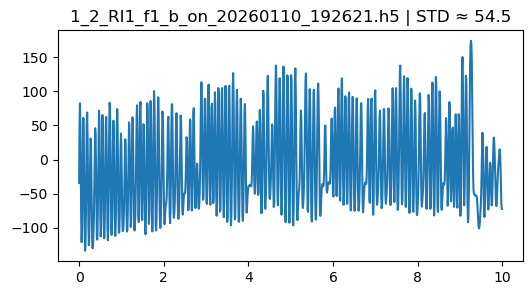

In [68]:
mid_std_file = qc_df[(qc_df["std"] > 40) & (qc_df["std"] < 80)]["file"].iloc[0]

mid_path = [f for f in all_files if os.path.basename(f) == mid_std_file][0]

rsp_mid, t_mid = load_resp_simple(mid_path)

plt.figure(figsize=(6,3))
plt.plot(t_mid[:1000], rsp_mid[:1000])
plt.title(f"{mid_std_file} | STD ≈ {qc_df[qc_df['file']==mid_std_file]['std'].values[0]:.1f}")
plt.show()


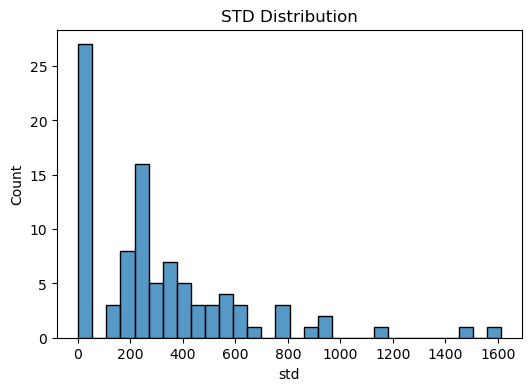

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(qc_df["std"], bins=30)
plt.title("STD Distribution")
plt.show()


In [85]:
cage5_files = [f for f in all_files if os.path.basename(f).startswith("5_")]
non_cage5_files = [f for f in all_files if not os.path.basename(f).startswith("5_")]

print("Cage 5 files:", len(cage5_files))
print("Non-cage 5 files:", len(non_cage5_files))


Cage 5 files: 12
Non-cage 5 files: 82


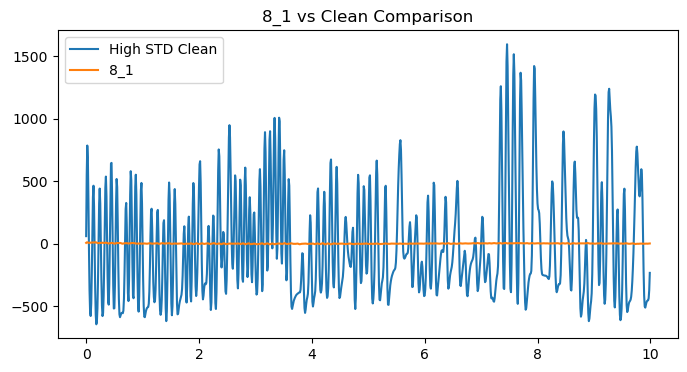

In [86]:
file_8_1 = [f for f in all_files if "8_1" in f][0]
clean_example = non_cage5_files[0]

rsp_8, t_8 = load_resp_simple(file_8_1)
rsp_clean, t_clean = load_resp_simple(clean_example)

plt.figure(figsize=(8,4))
plt.plot(t_clean[:1000], rsp_clean[:1000], label="High STD Clean")
plt.plot(t_8[:1000], rsp_8[:1000], label="8_1")
plt.legend()
plt.title("8_1 vs Clean Comparison")
plt.show()

In [87]:
import pandas as pd
import numpy as np

qc_metrics = []

for h5_file in all_files:
    rsp, t = load_resp_simple(h5_file)
    
    qc_metrics.append({
        "file": os.path.basename(h5_file),
        "cage5": os.path.basename(h5_file).startswith("5_"),
        "std": np.std(rsp)
    })

qc_df = pd.DataFrame(qc_metrics)

print("Mean STD (cage5):", qc_df[qc_df["cage5"]]["std"].mean())
print("Mean STD (non-cage5):", qc_df[~qc_df["cage5"]]["std"].mean())


Mean STD (cage5): 6.959855273487868
Mean STD (non-cage5): 352.253031257783


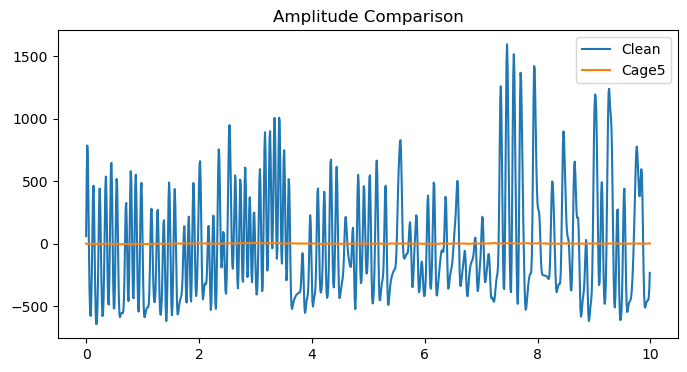

In [74]:
clean_example = non_cage5_files[0]
cage5_example = cage5_files[0]

rsp_clean, t_clean = load_resp_simple(clean_example)
rsp_c5, t_c5 = load_resp_simple(cage5_example)

plt.figure(figsize=(8,4))
plt.plot(t_clean[:1000], rsp_clean[:1000], label="Clean")
plt.plot(t_c5[:1000], rsp_c5[:1000], label="Cage5")
plt.legend()
plt.title("Amplitude Comparison")
plt.show()


In [79]:
qc_df.head()


,file,cage5,std
0,1_1_RI1_f1_d_on_20260111_164638.h5,False,398.290569
1,1_2_RI1_f2_f_off_20260109_165330.h5,False,326.210282
2,1_3_RI1_f1_c_off_20260110_130254.h5,False,277.362850
3,2_1_RI1_f2_h_on_20260110_145355.h5,False,250.412452
4,2_2_RI1_f1_b_off_20260109_150435.h5,False,428.592140


In [121]:
# Identify bad files
bad_files = qc_df[qc_df["std"] < 20]["file"]

# Extract subject IDs
bad_subjects = set(["_".join(f.split("_")[:2]) for f in bad_files])

print("Subjects flagged for exclusion:")
print(bad_subjects)
print("Total subjects removed:", len(bad_subjects))

# Filter respiration dataframe
df_resp_clean = df_clean[~df_clean["Subject"].isin(bad_subjects)].copy()

print("Remaining respiration subjects:", df_resp_clean["Subject"].nunique())


Subjects flagged for exclusion:
{'8_1', '5_2', '2_3', '6_2', '5_3', '4_1', '6_3', '5_1'}
Total subjects removed: 8
Remaining respiration subjects: 16


In [138]:
def extract_sex(subject):
    cage = int(subject.split("_")[0])
    return "Female" if cage <= 4 else "Male"

def extract_virus(subject):
    mouse = int(subject.split("_")[1])
    return "ChR" if mouse % 2 == 1 else "GFP"

df_resp_clean["Sex"] = df_resp_clean["Subject"].apply(extract_sex)
df_resp_clean["Virus"] = df_resp_clean["Subject"].apply(extract_virus)


In [139]:
df_resp_clean.groupby(["Sex", "Virus"])["Subject"].nunique()


Sex     Virus
Female  ChR      6
        GFP      4
Male    ChR      4
        GFP      2
Name: Subject, dtype: int64

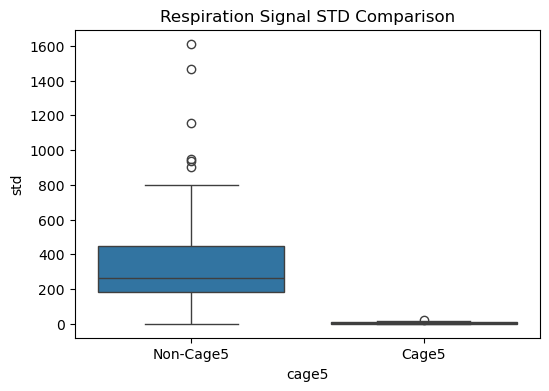

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="cage5", y="std", data=qc_df)
plt.xticks([0,1], ["Non-Cage5", "Cage5"])
plt.title("Respiration Signal STD Comparison")
plt.show()


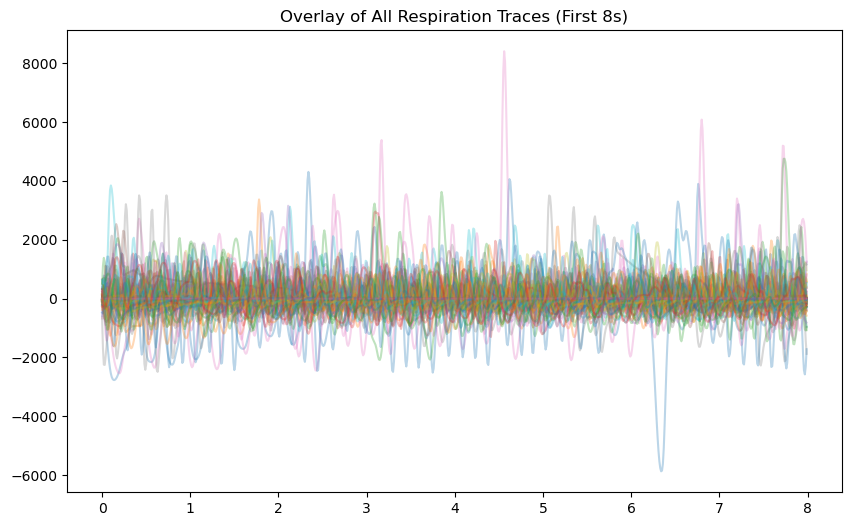

In [131]:
plt.figure(figsize=(10,6))

for h5_file in all_files:
    rsp, t = load_resp_simple(h5_file)
    plt.plot(t[:800], rsp[:800], alpha=0.3)

plt.title("Overlay of All Respiration Traces (First 8s)")
plt.show()


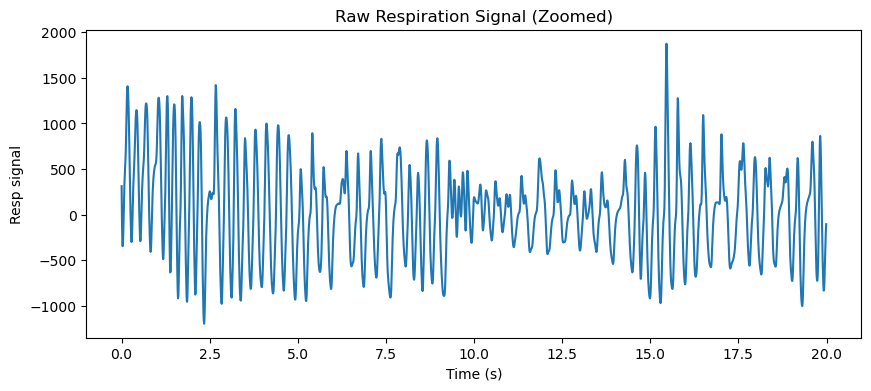

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(t[:2000], rsp[:2000])  # first ~20 seconds if sampling_rate=100
plt.xlabel("Time (s)")
plt.ylabel("Resp signal")
plt.title("Raw Respiration Signal (Zoomed)")
plt.show()


In [111]:
rows = []

for day, h5_dir in H5_DIRS.items():
    h5_files = glob.glob(os.path.join(h5_dir, "*.h5"))

    for h5_file in h5_files:
        rsp, t = load_resp_simple(h5_file)

        social_rate = get_sniff_respiratory_rate(
            signal=rsp,
            time=t,
            sniff_start=60,
            sniff_end=240,
            sampling_rate=100
        )

        rows.append({
            "File": os.path.basename(h5_file),
            "SocialRespRate": social_rate,
        })

df = pd.DataFrame(rows)


In [112]:
df["Laser"] = df["File"].str.contains("_on_").map(
    {True: "ON", False: "OFF"}
)

# Extract cage number (first number before "_")
df["Cage"] = df["File"].str.extract(r"^(\d+)").astype(int)

# Assign virus by cage parity
df["Virus"] = df["Cage"].apply(
    lambda x: "ChR" if x % 2 == 1 else "GFP"
)


df["Subject"] = df["File"].str.extract(r"(\d_\d)")


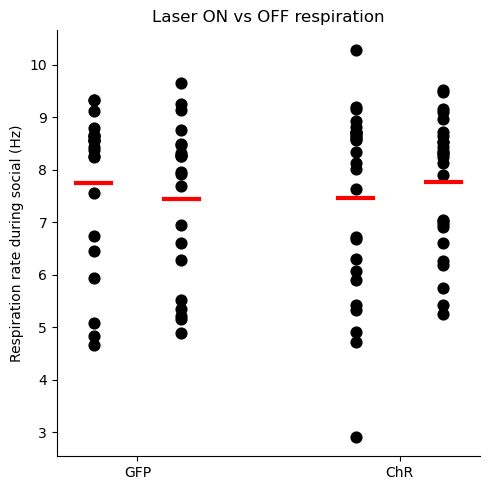

In [113]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

for i, virus in enumerate(["GFP", "ChR"]):
    sub = df[df["Virus"] == virus]

    for j, laser in enumerate(["OFF", "ON"]):
        vals = sub[sub["Laser"] == laser]["SocialRespRate"]

        x = i*3 + j
        ax.scatter(
            np.ones(len(vals))*x,
            vals,
            color="black",
            s=60
        )
        ax.plot(
            [x-0.2, x+0.2],
            [vals.mean(), vals.mean()],
            lw=3,
            color="red"
        )

ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["GFP", "ChR"])
ax.set_ylabel("Respiration rate during social (Hz)")
ax.set_title("Laser ON vs OFF respiration")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


replot without flat recs

In [151]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1️⃣ Select condition explicitly
# -----------------------------
df_plot = df_resp_clean.query("Condition == 'RI2'").copy()

# -----------------------------
# 2️⃣ Collapse in case duplicates exist
# (safety: ensures one value per subject per laser)
# -----------------------------
df_plot = (
    df_plot
    .groupby(["Subject", "Virus", "Laser"], as_index=False)
    .agg({"SocialRespRate": "mean"})
)

# -----------------------------
# 3️⃣ Keep only properly paired subjects
# -----------------------------
pair_counts = df_plot.groupby("Subject")["Laser"].nunique()
paired_subjects = pair_counts[pair_counts == 2].index

df_plot = df_plot[df_plot["Subject"].isin(paired_subjects)]

# -----------------------------
# 4️⃣ Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

xpos = {
    ("GFP", "OFF"): 0,
    ("GFP", "ON"):  1,
    ("ChR", "OFF"): 3,
    ("ChR", "ON"):  4,
}

for virus in ["GFP", "ChR"]:
    
    df_v = df_plot[df_plot["Virus"] == virus]
    
    for subject in df_v["Subject"].unique():
        
        sub_df = df_v[df_v["Subject"] == subject]
        
        off_row = sub_df[sub_df["Laser"] == "OFF"]
        on_row  = sub_df[sub_df["Laser"] == "ON"]
        
        if len(off_row) == 1 and len(on_row) == 1:
            
            off_val = off_row["SocialRespRate"].values[0]
            on_val  = on_row["SocialRespRate"].values[0]
            
            x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
            y = [off_val, on_val]
            
            ax.plot(x, y, color="gray", alpha=0.6, zorder=1)
            ax.scatter(x, y, color="black", s=55, zorder=2)

# -----------------------------
# 5️⃣ Mean bars
# -----------------------------
for (virus, laser), x in xpos.items():
    
    vals = df_plot[
        (df_plot["Virus"] == virus) &
        (df_plot["Laser"] == laser)
    ]["SocialRespRate"]
    
    if len(vals) > 0:
        ax.plot(
            [x - 0.2, x + 0.2],
            [vals.mean(), vals.mean()],
            color="red",
            lw=3,
            zorder=3
        )

# -----------------------------
# 6️⃣ Formatting
# -----------------------------
ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["GFP", "ChR"])
ax.set_ylabel("Respiration rate during social (Hz)")
ax.set_title("RI2: Laser ON vs OFF respiration (paired)")

ax.text(0, ax.get_ylim()[0], "OFF", ha="center", fontsize=11)
ax.text(1, ax.get_ylim()[0], "ON",  ha="center", fontsize=11)
ax.text(3, ax.get_ylim()[0], "OFF", ha="center", fontsize=11)
ax.text(4, ax.get_ylim()[0], "ON",  ha="center", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


UndefinedVariableError: name 'Condition' is not defined

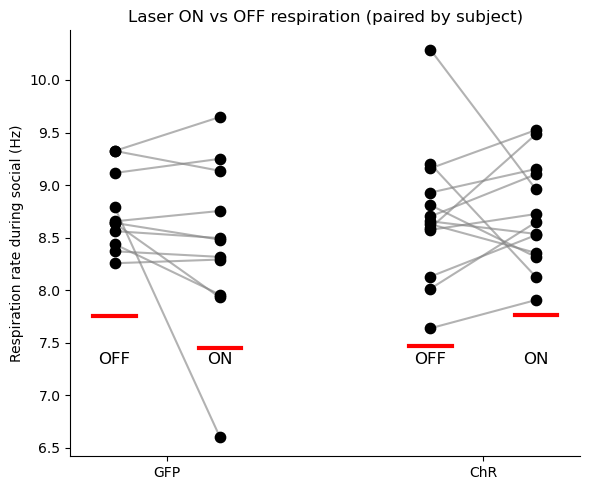

In [145]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

# x positions
xpos = {
    ("GFP", "OFF"): 0,
    ("GFP", "ON"):  1,
    ("ChR", "OFF"): 3,
    ("ChR", "ON"):  4,
}

for virus in ["GFP", "ChR"]:
    df_v = df[df["Virus"] == virus]

    for subject in df_v["Subject"].unique():
        sub_df = df_v[df_v["Subject"] == subject]

        # ensure we have both ON and OFF
        if set(sub_df["Laser"]) != {"ON", "OFF"}:
            continue

        off_val = sub_df[sub_df["Laser"] == "OFF"]["SocialRespRate"].values[0]
        on_val  = sub_df[sub_df["Laser"] == "ON"]["SocialRespRate"].values[0]

        x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
        y = [off_val, on_val]

        ax.plot(x, y, color="gray", alpha=0.6, zorder=1)
        ax.scatter(x, y, color="black", s=55, zorder=2)

# Mean bars
for (virus, laser), x in xpos.items():
    vals = df[(df["Virus"] == virus) & (df["Laser"] == laser)]["SocialRespRate"]
    ax.plot(
        [x - 0.2, x + 0.2],
        [vals.mean(), vals.mean()],
        color="red",
        lw=3,
        zorder=3
    )

# Formatting
ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["GFP", "ChR"])
ax.set_ylabel("Respiration rate during social (Hz)")
ax.set_title("Laser ON vs OFF respiration (paired by subject)")

# ON/OFF labels
ax.text(0, 7.3, "OFF", ha="center", fontsize=12)
ax.text(1, 7.3, "ON",  ha="center", fontsize=12)
ax.text(3, 7.3, "OFF", ha="center", fontsize=12)
ax.text(4, 7.3, "ON",  ha="center", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


Original N subjects: 24
After exclusion N subjects: 16

Subjects remaining:
['1_1', '1_2', '1_3', '2_1', '2_2', '3_1', '3_2', '3_3', '4_2', '4_3', '7_1', '7_2', '7_3', '8_2', '8_3', '9_1']

Laser counts per subject (should all be 2):
Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
3_1    2
3_2    2
3_3    2
4_2    2
4_3    2
7_1    2
7_2    2
7_3    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64



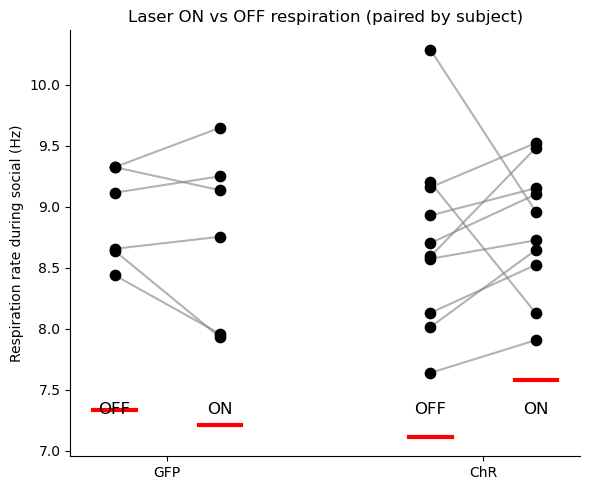

In [146]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1️⃣ EXCLUDE BAD SUBJECTS
# =====================================================

exclude_subjects = [
    "5_1", "5_2", "5_3",
    "2_3",
    "6_2", "6_3",
    "4_1",
    "8_1"
]

df_clean = df[~df["Subject"].isin(exclude_subjects)].copy()

# =====================================================
# 2️⃣ SANITY CHECKS
# =====================================================

print("Original N subjects:", df["Subject"].nunique())
print("After exclusion N subjects:", df_clean["Subject"].nunique())
print()

print("Subjects remaining:")
print(sorted(df_clean["Subject"].unique()))
print()

print("Laser counts per subject (should all be 2):")
print(df_clean.groupby("Subject")["Laser"].nunique())
print()

# =====================================================
# 3️⃣ PLOT PAIRED RESPIRATION
# =====================================================

fig, ax = plt.subplots(figsize=(6, 5))

# x positions
xpos = {
    ("GFP", "OFF"): 0,
    ("GFP", "ON"):  1,
    ("ChR", "OFF"): 3,
    ("ChR", "ON"):  4,
}

for virus in ["GFP", "ChR"]:
    df_v = df_clean[df_clean["Virus"] == virus]

    for subject in df_v["Subject"].unique():
        sub_df = df_v[df_v["Subject"] == subject]

        if set(sub_df["Laser"]) != {"ON", "OFF"}:
            continue

        off_val = sub_df[sub_df["Laser"] == "OFF"]["SocialRespRate"].values[0]
        on_val  = sub_df[sub_df["Laser"] == "ON"]["SocialRespRate"].values[0]

        x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
        y = [off_val, on_val]

        ax.plot(x, y, color="gray", alpha=0.6, zorder=1)
        ax.scatter(x, y, color="black", s=55, zorder=2)

# Mean bars
for (virus, laser), x in xpos.items():
    vals = df_clean[
        (df_clean["Virus"] == virus) &
        (df_clean["Laser"] == laser)
    ]["SocialRespRate"]

    ax.plot(
        [x - 0.2, x + 0.2],
        [vals.mean(), vals.mean()],
        color="red",
        lw=3,
        zorder=3
    )

# Formatting
ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["GFP", "ChR"])
ax.set_ylabel("Respiration rate during social (Hz)")
ax.set_title("Laser ON vs OFF respiration (paired by subject)")

ax.text(0, 7.3, "OFF", ha="center", fontsize=12)
ax.text(1, 7.3, "ON",  ha="center", fontsize=12)
ax.text(3, 7.3, "OFF", ha="center", fontsize=12)
ax.text(4, 7.3, "ON",  ha="center", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [147]:
import pingouin as pg

# Make sure df_clean has only paired subjects
df_stats = df_clean.copy()

# Run mixed ANOVA
aov = pg.mixed_anova(
    data=df_stats,
    dv="SocialRespRate",
    within="Laser",
    between="Virus",
    subject="Subject"
)

print(aov)


        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0        Virus  0.038503    1   14  0.038503  0.108449  0.746792  0.007687   
1        Laser  0.480325    1   14  0.480325  2.895256  0.110933  0.171365   
2  Interaction  0.658736    1   14  0.658736  3.970668  0.066168  0.220953   

   eps  
0  NaN  
1  1.0  
2  NaN  


Sex     Virus
Female  ChR      6
        GFP      4
Male    ChR      4
        GFP      2
Name: Subject, dtype: int64


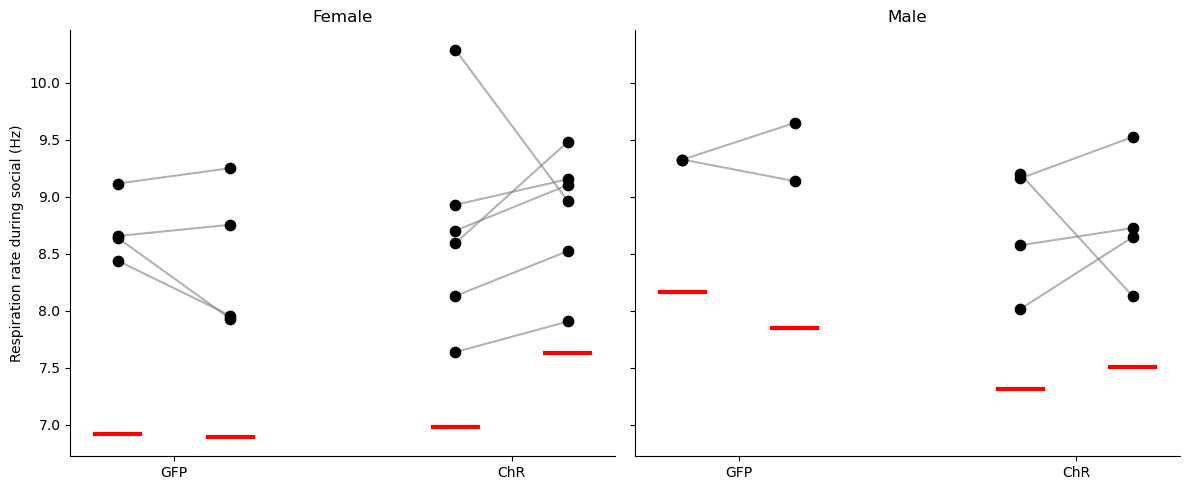

In [148]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1️⃣ EXCLUDE BAD SUBJECTS
# =====================================================

exclude_subjects = [
    "5_1", "5_2", "5_3",
    "2_3",
    "6_2", "6_3",
    "4_1",
    "8_1"
]

df_clean = df[~df["Subject"].isin(exclude_subjects)].copy()

# =====================================================
# 2️⃣ ADD SEX COLUMN (based on cage number)
# =====================================================

df_clean["Cage"] = df_clean["Subject"].str.split("_").str[0].astype(int)

df_clean["Sex"] = np.where(
    df_clean["Cage"].isin([1, 2, 3, 4]),
    "Female",
    "Male"
)

# =====================================================
# 3️⃣ SANITY CHECK
# =====================================================

print(df_clean.groupby(["Sex", "Virus"])["Subject"].nunique())

# =====================================================
# 4️⃣ PLOT SPLIT BY SEX
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sexes = ["Female", "Male"]

for ax, sex in zip(axes, sexes):

    df_sex = df_clean[df_clean["Sex"] == sex]

    xpos = {
        ("GFP", "OFF"): 0,
        ("GFP", "ON"):  1,
        ("ChR", "OFF"): 3,
        ("ChR", "ON"):  4,
    }

    for virus in ["GFP", "ChR"]:
        df_v = df_sex[df_sex["Virus"] == virus]

        for subject in df_v["Subject"].unique():
            sub_df = df_v[df_v["Subject"] == subject]

            if set(sub_df["Laser"]) != {"ON", "OFF"}:
                continue

            off_val = sub_df[sub_df["Laser"] == "OFF"]["SocialRespRate"].values[0]
            on_val  = sub_df[sub_df["Laser"] == "ON"]["SocialRespRate"].values[0]

            x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
            y = [off_val, on_val]

            ax.plot(x, y, color="gray", alpha=0.6, zorder=1)
            ax.scatter(x, y, color="black", s=55, zorder=2)

    # Mean bars
    for (virus, laser), x in xpos.items():
        vals = df_sex[
            (df_sex["Virus"] == virus) &
            (df_sex["Laser"] == laser)
        ]["SocialRespRate"]

        if len(vals) == 0:
            continue

        ax.plot(
            [x - 0.2, x + 0.2],
            [vals.mean(), vals.mean()],
            color="red",
            lw=3,
            zorder=3
        )

    ax.set_xticks([0.5, 3.5])
    ax.set_xticklabels(["GFP", "ChR"])
    ax.set_title(sex)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Respiration rate during social (Hz)")

plt.tight_layout()
plt.show()


In [134]:
# =====================================================
# BASIC OVERVIEW
# =====================================================

print("Shape of dataframe:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 10 rows:")
display(df.head(10))

# =====================================================
# SUBJECT SUMMARY
# =====================================================

print("\nUnique Subjects:")
print(sorted(df["Subject"].unique()))

print("\nNumber of subjects:", df["Subject"].nunique())

# =====================================================
# CHECK VIRUS GROUPS
# =====================================================

print("\nVirus counts:")
print(df["Virus"].value_counts())

# =====================================================
# CHECK LASER CONDITIONS
# =====================================================

print("\nLaser counts:")
print(df["Laser"].value_counts())

print("\nLaser per subject (should be 2 for paired design):")
print(df.groupby("Subject")["Laser"].nunique())

# =====================================================
# LOOK AT RESPIRATION VALUES
# =====================================================

print("\nRespiration summary stats:")
display(
    df.groupby(["Virus", "Laser"])["SocialRespRate"]
      .describe()
)

# =====================================================
# CHECK FOR DUPLICATES
# =====================================================

print("\nDuplicate rows (Virus, Subject, Laser):")
print(df.duplicated(subset=["Virus", "Subject", "Laser"]).sum())

# =====================================================
# CHECK ON vs OFF DIFFERENCE PER SUBJECT
# =====================================================

pivot = (
    df.pivot_table(
        index=["Virus", "Subject"],
        columns="Laser",
        values="SocialRespRate"
    )
)

pivot["ON_minus_OFF"] = pivot["ON"] - pivot["OFF"]

print("\nON - OFF differences per subject:")
display(pivot)


Shape of dataframe: (94, 6)

Columns:
Index(['File', 'SocialRespRate', 'Laser', 'Cage', 'Virus', 'Subject'], dtype='object')

First 10 rows:


,File,SocialRespRate,Laser,Cage,Virus,Subject
0,1_1_RI1_f1_d_on_20260111_164638.h5,9.152318,ON,1,ChR,1_1
1,1_2_RI1_f2_f_off_20260109_165330.h5,10.288113,OFF,1,ChR,1_2
2,1_3_RI1_f1_c_off_20260110_130254.h5,8.591796,OFF,1,ChR,1_3
3,2_1_RI1_f2_h_on_20260110_145355.h5,9.249470,ON,2,GFP,2_1
4,2_2_RI1_f1_b_off_20260109_150435.h5,8.654789,OFF,2,GFP,2_2
5,2_3_RI1_f2_f_on_20260110_132734.h5,8.291091,ON,2,GFP,2_3
6,3_1_RI1_f1_b_on_20260111_154618.h5,9.101620,ON,3,ChR,3_1
7,3_2_RI1_f1_a_off_20260114_161949.h5,8.129087,OFF,3,ChR,3_2
8,3_3_RI1_f1_c_on_20260111_162426.h5,7.905516,ON,3,ChR,3_3
9,4_1_RI1_f2_h_on_20260111_161337.h5,6.603175,ON,4,GFP,4_1



Unique Subjects:
['1_1', '1_2', '1_3', '2_1', '2_2', '2_3', '3_1', '3_2', '3_3', '4_1', '4_2', '4_3', '5_1', '5_2', '5_3', '6_2', '6_3', '7_1', '7_2', '7_3', '8_1', '8_2', '8_3', '9_1']

Number of subjects: 24

Virus counts:
Virus
ChR    52
GFP    42
Name: count, dtype: int64

Laser counts:
Laser
ON     47
OFF    47
Name: count, dtype: int64

Laser per subject (should be 2 for paired design):
Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
2_3    2
3_1    2
3_2    2
3_3    2
4_1    2
4_2    2
4_3    2
5_1    2
5_2    2
5_3    2
6_2    2
6_3    2
7_1    2
7_2    2
7_3    2
8_1    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64

Respiration summary stats:


count      mean       std       min       25%       50%  \
Virus Laser                                                            
ChR   OFF     26.0  7.465903  1.783521  2.915387  6.133016  8.233610   
      ON      26.0  7.760595  1.267904  5.248763  6.924294  8.276628   
GFP   OFF     21.0  7.750516  1.495973  4.666010  6.736201  8.438618   
      ON      21.0  7.450979  1.504391  4.903191  6.274820  7.957597   

                  75%        max  
Virus Laser                       
ChR   OFF    8.714508  10.288113  
      ON     8.617753   9.523018  
GFP   OFF    8.639853   9.325129  
      ON     8.480627   9.647353


Duplicate rows (Virus, Subject, Laser):
46

ON - OFF differences per subject:


Laser               OFF        ON  ON_minus_OFF
Virus Subject                                  
ChR   1_1      7.618287  7.671068      0.052780
      1_2      6.601750  7.933238      1.331488
      1_3      6.753745  7.457979      0.704235
      3_1      7.388044  7.679522      0.291478
      3_2      6.734448  7.566768      0.832319
      3_3      6.770688  7.463208      0.692520
      5_1      8.482918  8.329686     -0.153231
      5_2      8.763766  8.282250     -0.481516
      5_3      8.692607  8.485305     -0.207302
      7_1      7.627927  7.851468      0.223542
      7_2      7.956421  6.934557     -1.021865
      7_3      6.721232  7.846799      1.125567
      9_1      6.944908  7.385890      0.440982
GFP   2_1      6.890439  7.229941      0.339502
      2_2      6.746554  6.957065      0.210511
      2_3      8.247766  8.279607      0.031841
      4_1      8.792461  6.603175     -2.189286
      4_2      6.862572  6.729360     -0.133212
      4_3      7.186238  6.657826     -0.528412
      6_2      8.555599  7.720708     -0.834891
      6_3      8.474043  8.289440     -0.184603
      8_1      7.688027  7.377723     -0.310304
      8_2      8.439754  8.416754     -0.023000
      8_3      7.893198  7.275272     -0.617926

In [46]:
print(
    df.sort_values(["Virus", "Subject", "Laser"])
      [["Virus", "Subject", "Laser", "SocialRespRate"]]
)


   Virus Subject Laser  SocialRespRate
24   ChR     1_1   OFF        8.928348
0    ChR     1_1    ON        9.152318
1    ChR     1_2   OFF       10.288113
25   ChR     1_2    ON        8.960292
2    ChR     1_3   OFF        8.591796
26   ChR     1_3    ON        9.482227
30   ChR     3_1   OFF        8.701476
6    ChR     3_1    ON        9.101620
7    ChR     3_2   OFF        8.129087
31   ChR     3_2    ON        8.523029
32   ChR     3_3   OFF        7.637106
8    ChR     3_3    ON        7.905516
12   ChR     5_1    ON        8.354753
13   ChR     5_2   OFF        8.808680
36   ChR     5_2    ON        8.315864
14   ChR     5_3   OFF        8.654956
37   ChR     5_3    ON        8.535091
40   ChR     7_1   OFF        8.573362
17   ChR     7_1    ON        8.724313
18   ChR     7_2   OFF        9.200538
41   ChR     7_2    ON        8.127530
42   ChR     7_3   OFF        8.013650
19   ChR     7_3    ON        8.645307
46   ChR     9_1   OFF        9.159106
23   ChR     9_1    ON   

In [47]:
df.groupby("Subject")["Laser"].nunique()


Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
2_3    2
3_1    2
3_2    2
3_3    2
4_1    2
4_2    2
4_3    2
5_1    1
5_2    2
5_3    2
6_2    2
6_3    2
7_1    2
7_2    2
7_3    2
8_1    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64

In [48]:
# Extract cage number from filename
df["Cage"] = df["File"].str.split("_").str[0].astype(int)


In [49]:
df["Sex"] = np.where(df["Cage"] <= 4, "Female", "Male")


In [50]:
df.groupby(["Sex", "Virus"]).size()


Sex     Virus
Female  ChR      12
        GFP      12
Male    ChR      13
        GFP      10
dtype: int64

In [149]:
import statsmodels.formula.api as smf

# Make sure categorical
df["Sex"] = df["Sex"].astype("category")
df["Virus"] = df["Virus"].astype("category")
df["Laser"] = df["Laser"].astype("category")
df["Subject"] = df["Subject"].astype("category")

model = smf.mixedlm(
    "SocialRespRate ~ Sex * Virus * Laser",
    data=df,
    groups=df["Subject"]
)

result = model.fit()
print(result.summary())



KeyError: 'Sex'

In [30]:
# Count ON/OFF per subject
counts = df.groupby("Subject")["Laser"].nunique()

# Keep only subjects with both conditions
complete_subjects = counts[counts == 2].index

df_clean = df[df["Subject"].isin(complete_subjects)].copy()

print(df_clean.groupby("Subject")["Laser"].nunique())


Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
2_3    2
3_1    2
3_2    2
3_3    2
4_1    2
4_2    2
4_3    2
5_1    0
5_2    2
5_3    2
6_2    2
6_3    2
7_1    2
7_2    2
7_3    2
8_1    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30220\2652343073.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby("Subject")["Laser"].nunique()
C:\Users\sjs93\AppData\Local\Temp\ipykernel_30220\2652343073.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby("Subject")["Laser"].nunique())


In [34]:
counts = df.groupby("Subject")["Laser"].nunique()

complete_subjects = counts[counts == 2].index

df_clean = df[df["Subject"].isin(complete_subjects)].copy()

print(len(complete_subjects))


23


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30220\3742839223.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby("Subject")["Laser"].nunique()


In [35]:
df_clean["Sex"] = df_clean["Sex"].astype("category")
df_clean["Virus"] = df_clean["Virus"].astype("category")
df_clean["Laser"] = df_clean["Laser"].astype("category")
df_clean["Subject"] = df_clean["Subject"].astype("category")


In [27]:
import sys
print(sys.executable)


c:\Users\sjs93\anaconda3\envs\biopipeline-env\python.exe


In [36]:
model = smf.mixedlm(
    "SocialRespRate ~ Sex * Virus * Laser",
    data=df_clean,
    groups=df_clean["Subject"]
)

result = model.fit()

print(result.summary())


                     Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       SocialRespRate
No. Observations:        46            Method:                   REML          
No. Groups:              23            Scale:                    0.2342        
Min. group size:         2             Log-Likelihood:           -40.8717      
Max. group size:         2             Converged:                Yes           
Mean group size:         2.0                                                   
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             8.713    0.250 34.792 0.000  8.222  9.203
Sex[T.Male]                           0.022    0.354  0.063 0.950 -0.672  0.717
Virus[T.GFP]                         -0.063    0.354 -0.179 0